In [2]:
import sys
sys.path.append("..")

In [3]:
from src.config import CLASS_NAMES
from src.data_utils import validate_all_labels

In [4]:
validation_result = validate_all_labels()
validation_result

{'files_checked': 8099,
 'files_with_problems': 0,
 'empty_files': 0,
 'total_boxes': 75994,
 'class_counts': {0: 13802,
  1: 7730,
  2: 318,
  3: 8950,
  4: 134,
  5: 670,
  6: 759,
  7: 4647,
  8: 1945,
  9: 2790,
  10: 927,
  11: 15850,
  12: 11985,
  13: 157,
  14: 4560,
  15: 240,
  16: 530},
 'first_problems': []}

In [5]:
import pandas as pd
class_table = pd.DataFrame({
    "class_id": list(range(len(CLASS_NAMES))),
    "class_name": [CLASS_NAMES.get(i) for i in range(len(CLASS_NAMES))],
    "no_of_boxes": [validation_result["class_counts"].get(i,0) for i in range(len(CLASS_NAMES))]
})

class_table

,class_id,class_name,no_of_boxes
0,0,person,13802
1,1,ear,7730
2,2,ear-mufs,318
3,3,face,8950
4,4,face-guard,134
5,5,face-mask,670
6,6,foot,759
7,7,tool,4647
8,8,glasses,1945
9,9,gloves,2790


In [6]:
class_table.sort_values(by="no_of_boxes", ascending=False, inplace=True)

In [7]:
class_table

,class_id,class_name,no_of_boxes
11,11,hands,15850
0,0,person,13802
12,12,head,11985
3,3,face,8950
1,1,ear,7730
7,7,tool,4647
14,14,shoes,4560
9,9,gloves,2790
8,8,glasses,1945
10,10,helmet,927


In [16]:
from collections import Counter
from src.data_utils import read_label
from src.config import LABELS_DIR

image_count = Counter()

for path in LABELS_DIR.glob("*.txt"):
    labels = read_label(path)
    classes_in_image = {box["class_id"] for box in labels}
    for i in classes_in_image:
        image_count[i] += 1


In [17]:
class_table["no_of_images"] = class_table["class_id"].map(image_count)
class_table["boxes_per_image"] = class_table["no_of_boxes"] / class_table["no_of_images"].round(2)

In [18]:
class_table = class_table.sort_values(by="no_of_images", ascending=False).reset_index(drop=True)
print(class_table.to_string())

    class_id    class_name  no_of_boxes  no_of_images  boxes_per_image
0          0        person        13802          7617         1.811999
1         12          head        11985          6495         1.845266
2         11         hands        15850          6455         2.455461
3          3          face         8950          5646         1.585193
4          1           ear         7730          4884         1.582719
5          7          tool         4647          2257         2.058928
6          8       glasses         1945          1588         1.224811
7         14         shoes         4560          1570         2.904459
8          9        gloves         2790          1321         2.112036
9         10        helmet          927           466         1.989270
10         5     face-mask          670           395         1.696203
11         6          foot          759           347         2.187320
12         2      ear-mufs          318           223         1.426009
13    

In [21]:
class_table.to_csv("../docs/class_balance.csv", index=False)

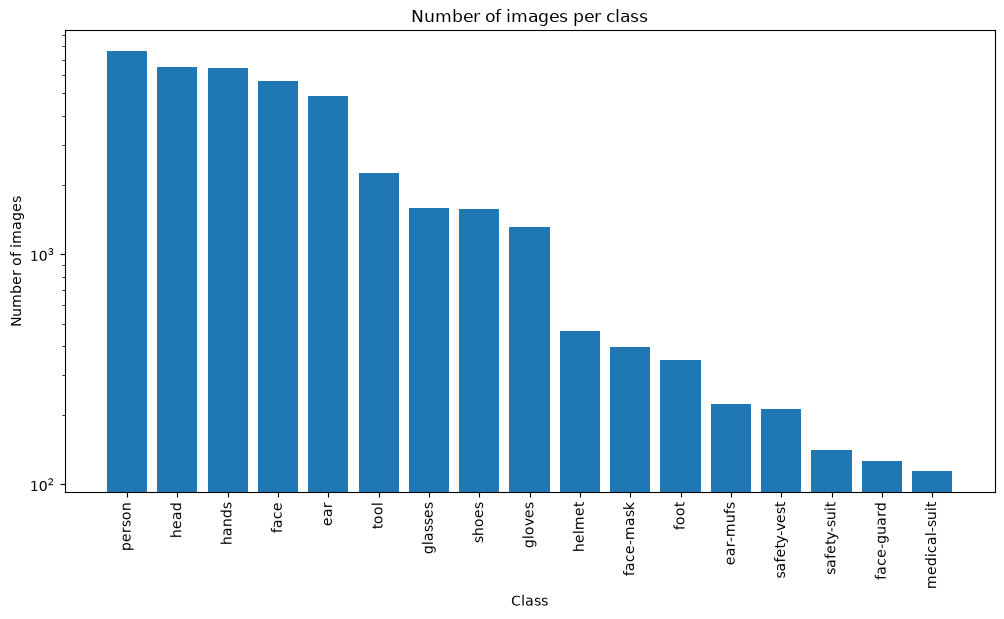

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(class_table["class_name"], class_table["no_of_images"], log=True)
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.savefig("../docs/class_balance.png")
plt.show()